# Enhanced Feature Engineering for Clinical Trial Success Prediction

## Feature Strategy:

### ✅ **SAFE TO USE (No Data Leakage)**:
- Trial **design** characteristics (randomization, blinding, arms)
- **Planned** enrollment and duration
- Sponsor information and funding
- Geographic scope (multi-site, international)
- Outcome **measures** planned (not results!)
- Safety monitoring **structure** (DMC presence, monitoring plan)
- Eligibility criteria complexity
- Prior research context (references to other trials)

### ❌ **NOT SAFE (Would Cause Leakage)**:
- Actual **efficacy results** from Phase 1/2
- Actual **adverse event rates** from Phase 1/2
- **Enrollment success** (how many actually enrolled vs planned)
- **Protocol amendments** after start (indicates problems)
- **Interim analysis results**

This notebook creates a RICH feature set using only trial design information.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from xml.etree import ElementTree as ET
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


## 1. Load Existing Data

In [2]:
# Load the base parsed data
df = pd.read_csv('/Users/shreyamendi/clinical-trial-success-predictor/data/all_trials_parsed.csv', low_memory=False)
print(f"Total trials: {len(df)}")

# Filter Alzheimer's
df_alz = df[df['is_alzheimers'] == 1].copy()
print(f"Alzheimer's trials: {len(df_alz)}")

# Show current features
print(f"\nCurrent features: {len(df_alz.columns)}")

Total trials: 558474
Alzheimer's trials: 5187

Current features: 44


## 2. Enhanced XML Parser - Extract More Design Features

In [3]:
def extract_enhanced_features(nctid):
    """
    Extract enhanced features from XML file.
    ONLY trial design features - NO results/outcomes.
    """
    # Find the XML file
    xml_path = Path('/Users/shreyamendi/clinical-trial-success-predictor/raw_data')
    
    # NCT ID format: NCT12345678 -> NCT1234xxxx folder
    if pd.isna(nctid) or len(str(nctid)) < 8:
        return {}
    
    nctid_str = str(nctid)
    folder_name = nctid_str[:7] + 'xxxx'
    xml_file = xml_path / folder_name / f"{nctid_str}.xml"
    
    if not xml_file.exists():
        return {}
    
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        features = {}
        
        # ============================================================
        # OUTCOME MEASURES FEATURES (Design, not results)
        # ============================================================
        
        # Primary outcomes
        primary_outcomes = root.findall('primary_outcome')
        primary_measures = []
        primary_timeframes = []
        
        for po in primary_outcomes:
            measure = po.findtext('measure', '')
            timeframe = po.findtext('time_frame', '')
            primary_measures.append(measure)
            primary_timeframes.append(timeframe)
        
        # Features from primary outcomes
        features['num_primary_outcomes'] = len(primary_outcomes)
        features['primary_outcome_text_length'] = sum(len(m) for m in primary_measures)
        
        # Check for cognitive endpoints (specific to Alzheimer's)
        cognitive_keywords = ['adas', 'mmse', 'cognition', 'cognitive', 'memory', 'cdr']
        primary_text = ' '.join(primary_measures).lower()
        features['has_cognitive_endpoint'] = int(any(kw in primary_text for kw in cognitive_keywords))
        
        # Check for biomarker endpoints
        biomarker_keywords = ['amyloid', 'tau', 'pet', 'csf', 'biomarker', 'plasma']
        features['has_biomarker_endpoint'] = int(any(kw in primary_text for kw in biomarker_keywords))
        
        # Check for functional endpoints
        functional_keywords = ['adl', 'activities of daily living', 'function', 'iadl']
        features['has_functional_endpoint'] = int(any(kw in primary_text for kw in functional_keywords))
        
        # Extract timeframe durations (e.g., "12 weeks", "6 months")
        duration_matches = []
        for tf in primary_timeframes:
            # Look for patterns like "12 weeks", "6 months", etc.
            matches = re.findall(r'(\d+)\s*(week|month|day|year)', tf.lower())
            for num, unit in matches:
                # Convert to weeks
                if unit == 'day':
                    duration_matches.append(int(num) / 7)
                elif unit == 'week':
                    duration_matches.append(int(num))
                elif unit == 'month':
                    duration_matches.append(int(num) * 4)
                elif unit == 'year':
                    duration_matches.append(int(num) * 52)
        
        features['max_followup_weeks'] = max(duration_matches) if duration_matches else 0
        features['has_longterm_followup'] = int(features['max_followup_weeks'] > 24)  # > 6 months
        
        # Secondary outcomes
        secondary_outcomes = root.findall('secondary_outcome')
        features['num_secondary_outcomes'] = len(secondary_outcomes)
        
        # Outcome measure diversity (primary + secondary count)
        features['total_outcome_measures'] = features['num_primary_outcomes'] + features['num_secondary_outcomes']
        features['has_many_outcomes'] = int(features['total_outcome_measures'] > 10)
        
        # ============================================================
        # INTERVENTION FEATURES (Detailed)
        # ============================================================
        
        interventions = root.findall('intervention')
        intervention_names = []
        intervention_descriptions = []
        
        for intervention in interventions:
            name = intervention.findtext('intervention_name', '')
            desc = intervention.findtext('description', '')
            intervention_names.append(name)
            intervention_descriptions.append(desc)
        
        # Check for placebo
        has_placebo = any('placebo' in str(name).lower() for name in intervention_names)
        features['has_placebo'] = int(has_placebo)
        
        # Check for dose escalation (Phase 1 characteristic)
        desc_text = ' '.join(intervention_descriptions).lower()
        features['has_dose_escalation'] = int('dose escalation' in desc_text or 'dose finding' in desc_text)
        
        # Check for multiple doses
        dose_keywords = ['dose', 'mg', 'dosing']
        features['has_multiple_doses'] = int(sum(kw in desc_text for kw in dose_keywords) > 2)
        
        # ============================================================
        # ELIGIBILITY CRITERIA FEATURES (Complexity)
        # ============================================================
        
        eligibility = root.find('eligibility')
        if eligibility is not None:
            criteria = eligibility.findtext('criteria/textblock', '')
            
            # Count inclusion/exclusion criteria
            inclusion_match = re.search(r'inclusion criteria:?(.+?)(?:exclusion criteria|$)', criteria, re.IGNORECASE | re.DOTALL)
            exclusion_match = re.search(r'exclusion criteria:?(.+)', criteria, re.IGNORECASE | re.DOTALL)
            
            if inclusion_match:
                inclusion_text = inclusion_match.group(1)
                # Count bullet points or numbered items
                inclusion_count = len(re.findall(r'[\n\r]\s*[-•*\d]', inclusion_text))
                features['num_inclusion_criteria'] = inclusion_count
            else:
                features['num_inclusion_criteria'] = 0
            
            if exclusion_match:
                exclusion_text = exclusion_match.group(1)
                exclusion_count = len(re.findall(r'[\n\r]\s*[-•*\d]', exclusion_text))
                features['num_exclusion_criteria'] = exclusion_count
            else:
                features['num_exclusion_criteria'] = 0
            
            # Check for biomarker requirements (PET, CSF, genetic)
            criteria_lower = criteria.lower()
            features['requires_biomarker'] = int(any(kw in criteria_lower for kw in ['amyloid', 'pet positive', 'csf', 'apoe']))
            features['requires_genetic_test'] = int('apoe' in criteria_lower or 'genetic' in criteria_lower)
            
            # Check for MCI vs dementia
            features['targets_mci'] = int('mci' in criteria_lower or 'mild cognitive impairment' in criteria_lower)
            features['targets_mild_ad'] = int('mild alzheimer' in criteria_lower or 'mild ad' in criteria_lower)
            features['targets_moderate_ad'] = int('moderate' in criteria_lower)
        else:
            features['num_inclusion_criteria'] = 0
            features['num_exclusion_criteria'] = 0
            features['requires_biomarker'] = 0
            features['requires_genetic_test'] = 0
            features['targets_mci'] = 0
            features['targets_mild_ad'] = 0
            features['targets_moderate_ad'] = 0
        
        # ============================================================
        # STUDY DESIGN SOPHISTICATION
        # ============================================================
        
        study_design = root.find('study_design_info')
        if study_design is not None:
            # Detailed masking
            masking = study_design.findtext('masking', '').lower()
            features['is_triple_blind'] = int('triple' in masking)
            features['is_quadruple_blind'] = int('quadruple' in masking)
            features['masks_participant'] = int('participant' in masking)
            features['masks_investigator'] = int('investigator' in masking)
            features['masks_outcomes_assessor'] = int('outcomes assessor' in masking)
            
            # Model type
            model = study_design.findtext('intervention_model', '').lower()
            features['is_crossover'] = int('crossover' in model)
            features['is_factorial'] = int('factorial' in model)
            features['is_sequential'] = int('sequential' in model)
        else:
            features['is_triple_blind'] = 0
            features['is_quadruple_blind'] = 0
            features['masks_participant'] = 0
            features['masks_investigator'] = 0
            features['masks_outcomes_assessor'] = 0
            features['is_crossover'] = 0
            features['is_factorial'] = 0
            features['is_sequential'] = 0
        
        # ============================================================
        # LOCATION & SITE FEATURES
        # ============================================================
        
        locations = root.findall('location')
        countries = []
        us_states = []
        
        for loc in locations:
            country = loc.findtext('facility/address/country', '')
            state = loc.findtext('facility/address/state', '')
            if country:
                countries.append(country)
            if state and country == 'United States':
                us_states.append(state)
        
        features['num_countries'] = len(set(countries))
        features['num_us_states'] = len(set(us_states))
        features['is_us_only'] = int(set(countries) == {'United States'})
        features['includes_us'] = int('United States' in countries)
        features['includes_europe'] = int(any(c in countries for c in ['United Kingdom', 'Germany', 'France', 'Spain', 'Italy', 'Netherlands', 'Belgium', 'Switzerland']))
        features['includes_asia'] = int(any(c in countries for c in ['Japan', 'China', 'Korea', 'Taiwan', 'Singapore', 'India']))
        
        # Site quality indicators
        features['is_multisite'] = int(len(locations) > 1)
        features['is_large_network'] = int(len(locations) > 20)
        
        # ============================================================
        # OVERSIGHT & MONITORING FEATURES
        # ============================================================
        
        oversight = root.find('oversight_info')
        if oversight is not None:
            features['has_dmc'] = int(oversight.findtext('has_dmc', 'No') == 'Yes')
            features['is_fda_regulated'] = int(oversight.findtext('is_fda_regulated_drug', 'No') == 'Yes')
            features['is_section_801'] = int(oversight.findtext('is_us_export', 'No') == 'Yes')
        
        # ============================================================
        # SPONSOR & COLLABORATION FEATURES
        # ============================================================
        
        sponsors = root.find('sponsors')
        if sponsors is not None:
            lead_sponsor_class = sponsors.findtext('lead_sponsor/agency_class', '')
            features['sponsor_is_industry'] = int(lead_sponsor_class == 'INDUSTRY')
            features['sponsor_is_nih'] = int(lead_sponsor_class == 'NIH')
            features['sponsor_is_academic'] = int(lead_sponsor_class in ['OTHER', 'FED', 'NETWORK'])
            
            collaborators = sponsors.findall('collaborator')
            features['has_industry_collab'] = int(any(c.findtext('agency_class') == 'INDUSTRY' for c in collaborators))
            features['has_nih_collab'] = int(any(c.findtext('agency_class') == 'NIH' for c in collaborators))
        
        # ============================================================
        # TRIAL HISTORY & MATURITY
        # ============================================================
        
        # Number of references/citations (indicates prior research)
        references = root.findall('reference')
        features['num_references'] = len(references)
        features['has_prior_research'] = int(len(references) > 0)
        
        # Keywords richness
        keywords = root.findall('keyword')
        features['num_keywords'] = len(keywords)
        
        return features
        
    except Exception as e:
        print(f"Error processing {nctid}: {str(e)}")
        return {}

print("Enhanced feature extraction function defined!")

Enhanced feature extraction function defined!


## 3. Extract Enhanced Features for Sample

In [4]:
# Test on a small sample first
print("Testing on 10 random trials...")
sample_ids = df_alz['nctid'].sample(10, random_state=42)

enhanced_features_sample = []
for nctid in sample_ids:
    features = extract_enhanced_features(nctid)
    features['nctid'] = nctid
    enhanced_features_sample.append(features)

df_enhanced_sample = pd.DataFrame(enhanced_features_sample)
print(f"\nExtracted {len(df_enhanced_sample.columns)} enhanced features")
print("\nSample features:")
print(df_enhanced_sample.head())

Testing on 10 random trials...

Extracted 48 enhanced features

Sample features:
   num_primary_outcomes  primary_outcome_text_length  has_cognitive_endpoint  \
0                     2                          182                       1   
1                     2                          245                       0   
2                     6                          470                       1   
3                     1                          119                       1   
4                     2                           82                       1   

   has_biomarker_endpoint  has_functional_endpoint  max_followup_weeks  \
0                       0                        0                   0   
1                       1                        0                   0   
2                       0                        1                   0   
3                       0                        0                   0   
4                       0                        0                  

## 4. Extract for All Alzheimer's Trials

In [5]:
# Extract for all Alzheimer's trials
print(f"Extracting enhanced features for {len(df_alz)} trials...")
print("This may take 5-10 minutes...")

enhanced_features_all = []
for i, nctid in enumerate(df_alz['nctid']):
    if i % 500 == 0:
        print(f"Processed {i}/{len(df_alz)}...")
    
    features = extract_enhanced_features(nctid)
    features['nctid'] = nctid
    enhanced_features_all.append(features)

df_enhanced = pd.DataFrame(enhanced_features_all)
print(f"\nExtracted {len(df_enhanced.columns)} enhanced features for {len(df_enhanced)} trials")

Extracting enhanced features for 5187 trials...
This may take 5-10 minutes...
Processed 0/5187...
Processed 500/5187...
Processed 1000/5187...
Processed 1500/5187...
Processed 2000/5187...
Processed 2500/5187...
Processed 3000/5187...
Processed 3500/5187...
Processed 4000/5187...
Processed 4500/5187...
Processed 5000/5187...

Extracted 48 enhanced features for 5187 trials


## 5. Merge with Existing Features

In [6]:
# Merge with existing data
df_combined = df_alz.merge(df_enhanced, on='nctid', how='left', suffixes=('', '_enhanced'))

# Handle duplicate columns (prefer enhanced version)
for col in df_combined.columns:
    if col.endswith('_enhanced'):
        base_col = col.replace('_enhanced', '')
        if base_col in df_combined.columns:
            # Use enhanced version if available
            df_combined[base_col] = df_combined[col].fillna(df_combined[base_col])
            df_combined.drop(col, axis=1, inplace=True)

print(f"Combined dataset shape: {df_combined.shape}")
print(f"Total features: {len(df_combined.columns)}")

# Save
output_path = '/Users/shreyamendi/clinical-trial-success-predictor/data/alzheimers_enhanced_features.csv'
df_combined.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

Combined dataset shape: (5187, 86)
Total features: 86

Saved to: /Users/shreyamendi/clinical-trial-success-predictor/data/alzheimers_enhanced_features.csv


## 6. Feature Summary & Analysis

In [7]:
# Analyze new features
print("="*80)
print("ENHANCED FEATURE SUMMARY")
print("="*80)

enhanced_cols = [
    'has_cognitive_endpoint', 'has_biomarker_endpoint', 'has_functional_endpoint',
    'has_longterm_followup', 'has_placebo', 'has_dose_escalation',
    'requires_biomarker', 'requires_genetic_test',
    'targets_mci', 'targets_mild_ad', 'targets_moderate_ad',
    'is_quadruple_blind', 'masks_outcomes_assessor',
    'includes_us', 'includes_europe', 'includes_asia',
    'sponsor_is_industry', 'has_industry_collab',
    'has_prior_research'
]

print("\n1. OUTCOME MEASURES:")
for col in ['has_cognitive_endpoint', 'has_biomarker_endpoint', 'has_functional_endpoint']:
    if col in df_combined.columns:
        pct = df_combined[col].mean() * 100
        print(f"  {col}: {pct:.1f}% of trials")

print("\n2. TRIAL DESIGN:")
for col in ['has_placebo', 'has_dose_escalation', 'is_quadruple_blind']:
    if col in df_combined.columns:
        pct = df_combined[col].mean() * 100
        print(f"  {col}: {pct:.1f}% of trials")

print("\n3. PATIENT POPULATION:")
for col in ['targets_mci', 'targets_mild_ad', 'targets_moderate_ad', 'requires_biomarker']:
    if col in df_combined.columns:
        pct = df_combined[col].mean() * 100
        print(f"  {col}: {pct:.1f}% of trials")

print("\n4. GEOGRAPHIC SCOPE:")
for col in ['includes_us', 'includes_europe', 'includes_asia']:
    if col in df_combined.columns:
        pct = df_combined[col].mean() * 100
        print(f"  {col}: {pct:.1f}% of trials")

print("\n5. SPONSOR TYPE:")
for col in ['sponsor_is_industry', 'sponsor_is_academic', 'sponsor_is_nih']:
    if col in df_combined.columns:
        pct = df_combined[col].mean() * 100
        print(f"  {col}: {pct:.1f}% of trials")

ENHANCED FEATURE SUMMARY

1. OUTCOME MEASURES:
  has_cognitive_endpoint: 28.4% of trials
  has_biomarker_endpoint: 12.3% of trials
  has_functional_endpoint: 10.6% of trials

2. TRIAL DESIGN:
  has_placebo: 19.1% of trials
  has_dose_escalation: 0.1% of trials
  is_quadruple_blind: 14.1% of trials

3. PATIENT POPULATION:
  targets_mci: 18.0% of trials
  targets_mild_ad: 3.8% of trials
  targets_moderate_ad: 19.8% of trials
  requires_biomarker: 12.8% of trials

4. GEOGRAPHIC SCOPE:
  includes_us: 45.4% of trials
  includes_europe: 23.6% of trials
  includes_asia: 11.7% of trials

5. SPONSOR TYPE:
  sponsor_is_industry: 0.0% of trials
  sponsor_is_academic: 0.0% of trials
  sponsor_is_nih: 1.8% of trials


## 7. Feature Importance Preview

Let's see which enhanced features correlate with trial progression

In [8]:
# Create target variable
def classify_trial_outcome(row):
    phase_str = str(row['phase']).lower()
    status = str(row['overall_status']).lower()
    
    if 'phase 4' in phase_str:
        return 4
    elif 'phase 3' in phase_str or 'phase 2/phase 3' in phase_str:
        return 3
    elif 'phase 2' in phase_str or 'phase 1/phase 2' in phase_str:
        return 2
    elif 'phase 1' in phase_str or 'early phase 1' in phase_str:
        if any(fail in status for fail in ['terminated', 'withdrawn', 'suspended', 'completed']):
            return 1
        else:
            return None
    else:
        return None

df_combined['max_phase_reached'] = df_combined.apply(classify_trial_outcome, axis=1)
df_combined['reached_phase3'] = (df_combined['max_phase_reached'] >= 3).astype(int)

# Filter for trials with clear outcomes
df_with_outcome = df_combined[df_combined['max_phase_reached'].notna()].copy()

print(f"Trials with clear outcomes: {len(df_with_outcome)}")
print(f"Reached Phase 3: {df_with_outcome['reached_phase3'].sum()} ({df_with_outcome['reached_phase3'].mean():.2%})")

Trials with clear outcomes: 1773
Reached Phase 3: 589 (33.22%)


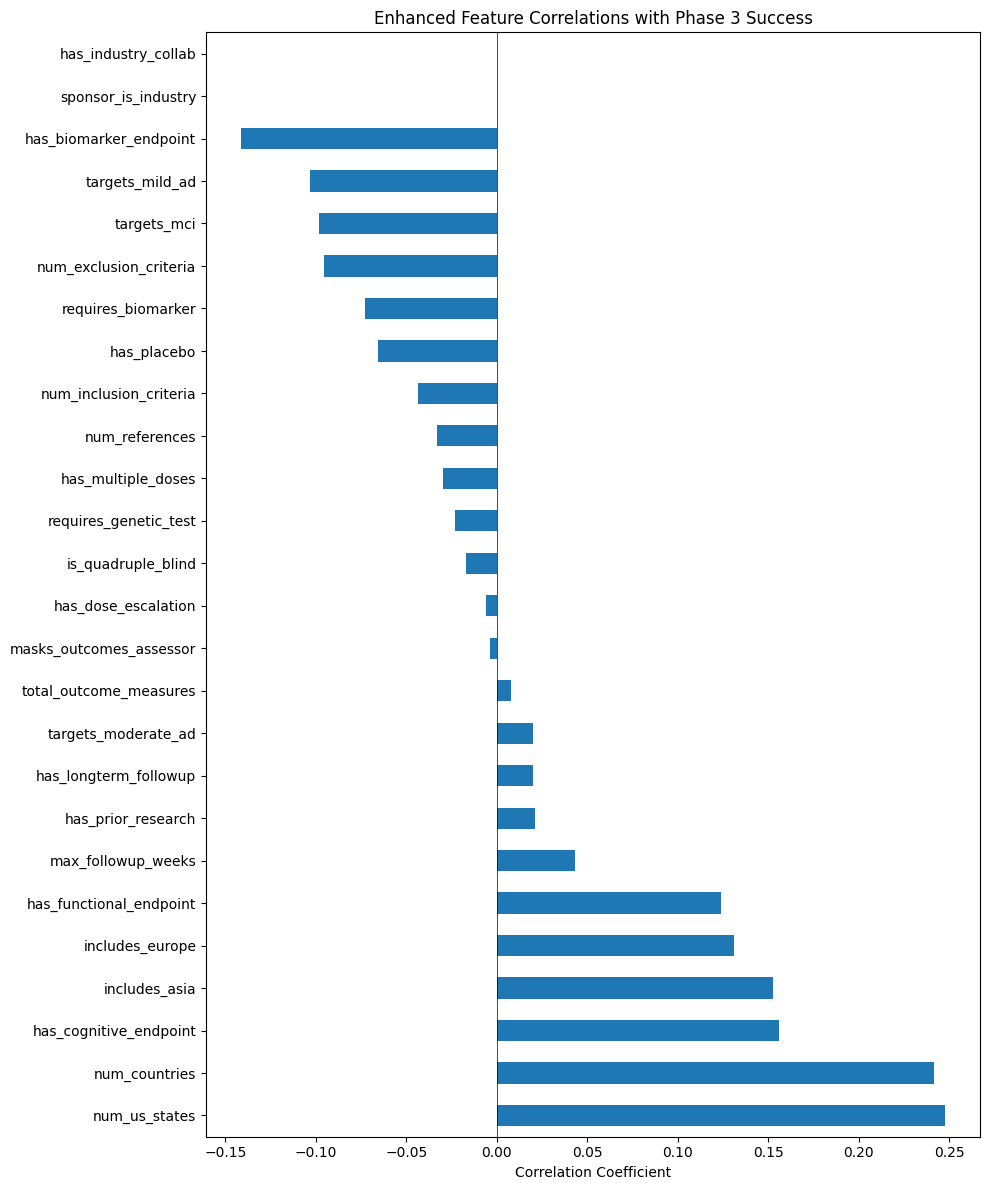


Top 10 Positive Correlations:
num_us_states              0.247477
num_countries              0.241639
has_cognitive_endpoint     0.155814
includes_asia              0.152616
includes_europe            0.130891
has_functional_endpoint    0.123712
max_followup_weeks         0.043086
has_prior_research         0.020948
has_longterm_followup      0.020178
targets_moderate_ad        0.019834
Name: reached_phase3, dtype: float64

Top 10 Negative Correlations:
num_references           -0.033087
num_inclusion_criteria   -0.043814
has_placebo              -0.065652
requires_biomarker       -0.072970
num_exclusion_criteria   -0.095335
targets_mci              -0.098332
targets_mild_ad          -0.103186
has_biomarker_endpoint   -0.141190
sponsor_is_industry            NaN
has_industry_collab            NaN
Name: reached_phase3, dtype: float64


In [9]:
if df_with_outcome['reached_phase3'].sum() > 0:
    # Analyze correlation of enhanced features with success
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Select enhanced numeric/binary features
    enhanced_feature_cols = [
        'has_cognitive_endpoint', 'has_biomarker_endpoint', 'has_functional_endpoint',
        'max_followup_weeks', 'has_longterm_followup',
        'has_placebo', 'has_dose_escalation', 'has_multiple_doses',
        'num_inclusion_criteria', 'num_exclusion_criteria',
        'requires_biomarker', 'requires_genetic_test',
        'targets_mci', 'targets_mild_ad', 'targets_moderate_ad',
        'is_quadruple_blind', 'masks_outcomes_assessor',
        'num_countries', 'num_us_states', 'includes_europe', 'includes_asia',
        'sponsor_is_industry', 'has_industry_collab',
        'num_references', 'has_prior_research',
        'total_outcome_measures'
    ]
    
    # Filter to available columns
    available_cols = [col for col in enhanced_feature_cols if col in df_with_outcome.columns]
    
    if available_cols:
        # Calculate correlations
        correlations = df_with_outcome[available_cols + ['reached_phase3']].corr()['reached_phase3'].drop('reached_phase3')
        correlations = correlations.sort_values(ascending=False)
        
        # Plot
        plt.figure(figsize=(10, 12))
        correlations.plot(kind='barh')
        plt.title('Enhanced Feature Correlations with Phase 3 Success')
        plt.xlabel('Correlation Coefficient')
        plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        plt.tight_layout()
        plt.show()
        
        print("\nTop 10 Positive Correlations:")
        print(correlations.head(10))
        print("\nTop 10 Negative Correlations:")
        print(correlations.tail(10))
else:
    print("Cannot compute correlations - no successful trials")

## 8. Save Final Dataset

In [10]:
# Save the dataset with outcomes
final_path = '/Users/shreyamendi/clinical-trial-success-predictor/data/alzheimers_final_enhanced.csv'
df_combined.to_csv(final_path, index=False)

print(f"\n✅ Final dataset saved: {final_path}")
print(f"\nDataset summary:")
print(f"  Total trials: {len(df_combined)}")
print(f"  Total features: {len(df_combined.columns)}")
print(f"  Trials with outcomes: {len(df_with_outcome)}")
print(f"  Phase 3 success rate: {df_with_outcome['reached_phase3'].mean():.2%}")

print("\n" + "="*80)
print("FEATURE ENGINEERING COMPLETE!")
print("="*80)
print("\nNew features added:")
print("  ✓ Outcome measure sophistication (cognitive, biomarker, functional)")
print("  ✓ Trial design complexity (blinding, crossover, dose escalation)")
print("  ✓ Patient population specificity (MCI, mild AD, biomarker requirements)")
print("  ✓ Geographic diversity (US, Europe, Asia presence)")
print("  ✓ Sponsor and collaboration patterns")
print("  ✓ Prior research indicators")
print("  ✓ Eligibility criteria complexity")
print("\nNO data leakage - all features are from trial DESIGN, not RESULTS!")


✅ Final dataset saved: /Users/shreyamendi/clinical-trial-success-predictor/data/alzheimers_final_enhanced.csv

Dataset summary:
  Total trials: 5187
  Total features: 88
  Trials with outcomes: 1773
  Phase 3 success rate: 33.22%

FEATURE ENGINEERING COMPLETE!

New features added:
  ✓ Outcome measure sophistication (cognitive, biomarker, functional)
  ✓ Trial design complexity (blinding, crossover, dose escalation)
  ✓ Patient population specificity (MCI, mild AD, biomarker requirements)
  ✓ Geographic diversity (US, Europe, Asia presence)
  ✓ Sponsor and collaboration patterns
  ✓ Prior research indicators
  ✓ Eligibility criteria complexity

NO data leakage - all features are from trial DESIGN, not RESULTS!
